<a href="https://colab.research.google.com/github/raajlearner/retail-sales-analytics-forecasting/blob/main/Retail_Analytic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded=files.upload()

Saving Features data set.csv to Features data set (5).csv
Saving sales data-set.csv to sales data-set (5).csv
Saving stores data-set.csv to stores data-set (5).csv


In [4]:
import pandas as pd
import numpy as np
import io

In [5]:
features_df=pd.read_csv(io.BytesIO(uploaded['Features data set (5).csv']))
sales_df=pd.read_csv(io.BytesIO(uploaded['sales data-set (5).csv']))
stores_df=pd.read_csv(io.BytesIO(uploaded['stores data-set (5).csv']))

In [6]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [7]:
sales_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [8]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [9]:
features_df.shape

(8190, 12)

In [10]:
sales_df.shape

(421570, 5)

In [11]:
stores_df.shape

(45, 3)

In [12]:
df= sales_df.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
df=df.merge(stores_df,on='Store',how='left')

In [13]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [14]:
df.shape

(421570, 16)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [16]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


In [17]:
df['Date']=pd.to_datetime(df['Date'], dayfirst=True)

In [18]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)   #filling missing markdown columns

In [19]:
df['CPI'].isnull().any()

np.False_

In [20]:
# Time features
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter

In [21]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Week,Month,Year,Quarter
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010,1
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010,1
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010,1
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,2,2010,1
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,2010,1


In [32]:
# Store size category
df['StoreSizeCategory'] = pd.qcut(df['Size'], 3, labels=['Small','Medium','Large'])

### STATISTICAL ANALYSIS & EDA

##### Import all libraries

In [22]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error

from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

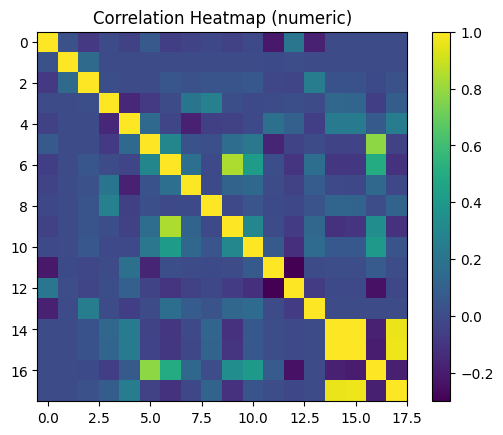

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# Correlation matrix
corr = df.corr(numeric_only=True)
plt.figure()
plt.imshow(corr)
plt.title('Correlation Heatmap (numeric)')
plt.colorbar()
plt.show()

In [24]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
# Key correlations with target
corr_target = corr['Weekly_Sales'].sort_values(ascending=False)

print('Top correlations with Weekly_Sales:', corr_target.head(10))
print('Negative correlations:', corr_target.tail(10))

Top correlations with Weekly_Sales: Weekly_Sales    1.000000
Size            0.243828
Dept            0.148032
MarkDown5       0.050465
MarkDown1       0.047172
MarkDown3       0.038562
MarkDown4       0.037467
Month           0.028409
Week            0.027673
Quarter         0.023838
Name: Weekly_Sales, dtype: float64
Negative correlations: Week            0.027673
Quarter         0.023838
MarkDown2       0.020716
IsHoliday       0.012774
Fuel_Price     -0.000120
Temperature    -0.002312
Year           -0.010111
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64


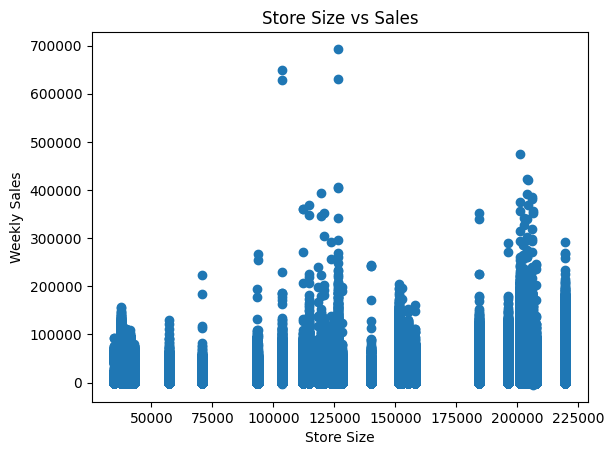

In [26]:
# Store size impact
size_sales = df.groupby('Size')['Weekly_Sales'].mean()
plt.figure()
plt.scatter(df['Size'], df['Weekly_Sales'])
plt.title('Store Size vs Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.show()

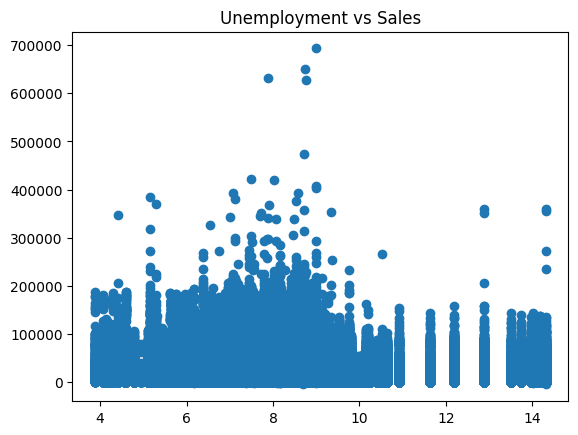

In [27]:
# Economic indicators impact
plt.figure()
plt.scatter(df['Unemployment'], df['Weekly_Sales'])
plt.title('Unemployment vs Sales')
plt.show()

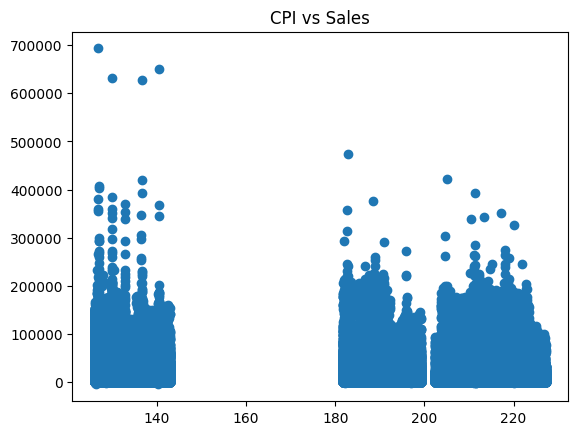

In [28]:
plt.figure()
plt.scatter(df['CPI'], df['Weekly_Sales'])
plt.title('CPI vs Sales')
plt.show()

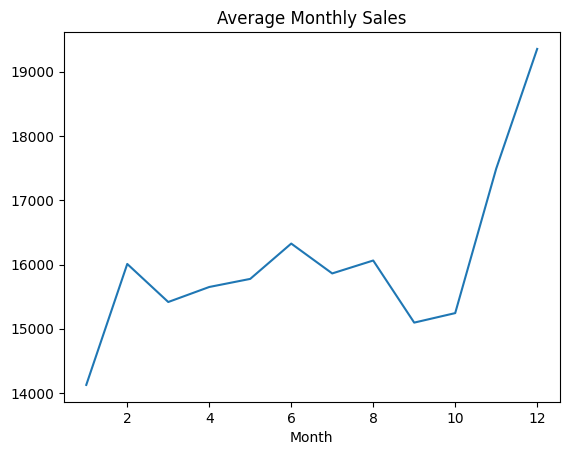

In [29]:
# Time-based seasonality
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(title='Average Monthly Sales')
plt.show()


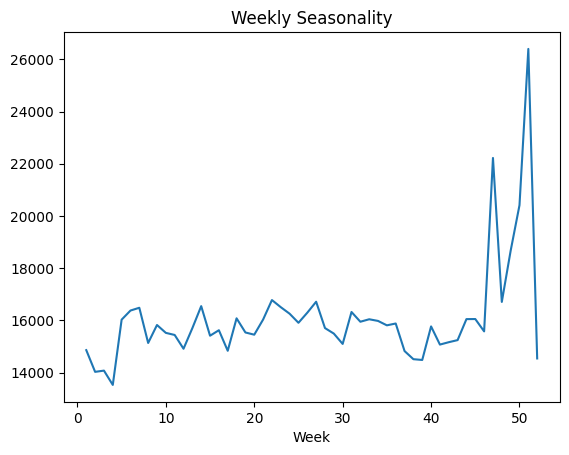

In [30]:
weekly_sales = df.groupby('Week')['Weekly_Sales'].mean()
weekly_sales.plot(title='Weekly Seasonality')
plt.show()

### Feature engineering

In [33]:
# Encode categorical
df = pd.get_dummies(df, columns=['Type','StoreSizeCategory'], drop_first=True)


In [34]:
# Promotion features
df['TotalMarkdown'] = df[markdown_cols].sum(axis=1)
df['PromoActive'] = (df['TotalMarkdown'] > 0).astype(int)

# Economic stress feature
df['EconomicStress'] = df['Unemployment'] * df['Fuel_Price']

###CUSTOMER SEGMENTATION (STORE-DEPT)

In [35]:
seg = df.groupby(['Store','Dept']).agg({
    'Weekly_Sales':'mean',
    'TotalMarkdown':'mean',
    'Unemployment':'mean',
    'CPI':'mean'
}).reset_index()

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42)
seg['Cluster'] = kmeans.fit_predict(seg.drop(['Store','Dept'], axis=1))

print(seg.head())

   Store  Dept  Weekly_Sales  TotalMarkdown  Unemployment         CPI  Cluster
0      1     1  22513.322937    7303.748741       7.61042  215.996892        3
1      1     2  46102.090420    7303.748741       7.61042  215.996892        1
2      1     3  13150.478042    7303.748741       7.61042  215.996892        3
3      1     4  36964.154476    7303.748741       7.61042  215.996892        1
4      1     5  24257.941119    7303.748741       7.61042  215.996892        3


###MARKET BASKET ANALYSIS

###DEMAND FORECASTING MODEL

In [37]:
# sample data
sample_df = df.sample(frac=0.2, random_state=42)

In [38]:
# keeping top departments only
top_depts = sample_df['Dept'].value_counts().nlargest(20).index
sample_df = sample_df[sample_df['Dept'].isin(top_depts)]

In [39]:
# build basket (NO DATE)
basket = sample_df.groupby(['Store','Dept'])['Weekly_Sales'].sum().unstack().fillna(0)

In [40]:
# binary matrix
basket = (basket > 0).astype(int)

In [41]:
# apriori (lighter thresholds)
freq_items = apriori(basket, min_support=0.1, use_colnames=True)

In [ ]:
# rules
rules = association_rules(freq_items, metric='lift', min_threshold=1.2)
print(rules.head())